In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("shopping_behavior.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
print("First 5 Rows:")
print(df.head())


First 5 Rows:
   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

   Shipping Type Discount Applied Promo Co

In [6]:
print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

## Missing Values
print("\nMissing Values:")
print(df.isnull().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3

In [8]:
## Total Revenue
total_revenue = df["Purchase Amount (USD)"].sum()
print(f"\nTotal Revenue: {total_revenue}")



Total Revenue: 233081



Revenue by Category:
 Category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64


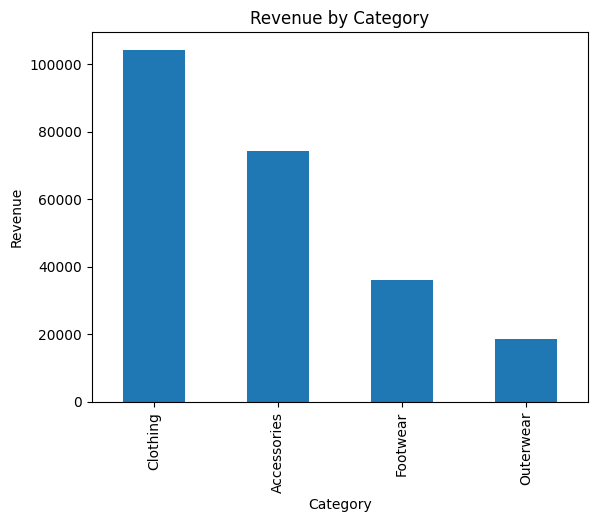

In [9]:
# Revenue by Category
category_sales = df.groupby("Category")["Purchase Amount (USD)"].sum().sort_values(ascending=False)
print("\nRevenue by Category:\n", category_sales)

# Plot
category_sales.plot(kind='bar')
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()



Revenue by Gender:
 Gender
Female     75191
Male      157890
Name: Purchase Amount (USD), dtype: int64


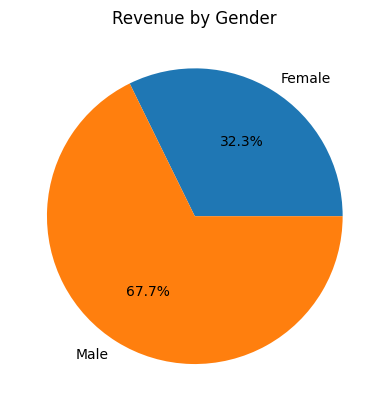

In [10]:
# Revenue by Gender
gender_sales = df.groupby("Gender")["Purchase Amount (USD)"].sum()
print("\nRevenue by Gender:\n", gender_sales)

# Plot
gender_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Revenue by Gender")
plt.ylabel("")
plt.show()


Revenue by Age Group:
 Age Group
Adult         92948
Middle Age    67711
Senior        43164
Young         29258
Name: Purchase Amount (USD), dtype: int64


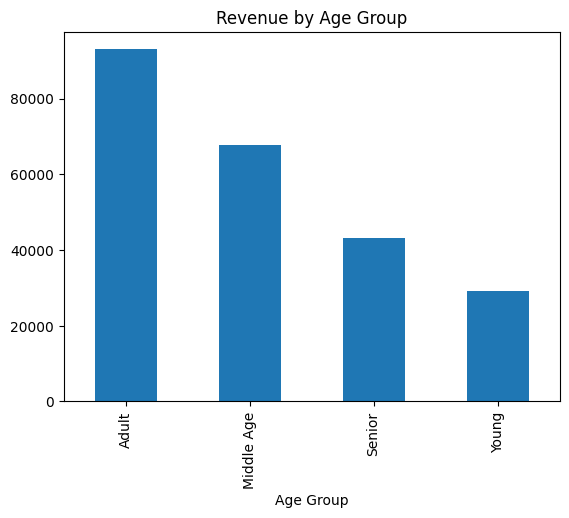

In [11]:
# Revenue by Age Group

def age_group(age):
    if age < 25:
        return "Young"
    elif age <= 45:
        return "Adult"
    elif age <= 60:
        return "Middle Age"
    else:
        return "Senior"

df["Age Group"] = df["Age"].apply(age_group)

age_sales = df.groupby("Age Group")["Purchase Amount (USD)"].sum()
print("\nRevenue by Age Group:\n", age_sales)

age_sales.plot(kind='bar')
plt.title("Revenue by Age Group")
plt.show()


Sales by Season:
 Season
Fall      60018
Spring    58679
Summer    55777
Winter    58607
Name: Purchase Amount (USD), dtype: int64


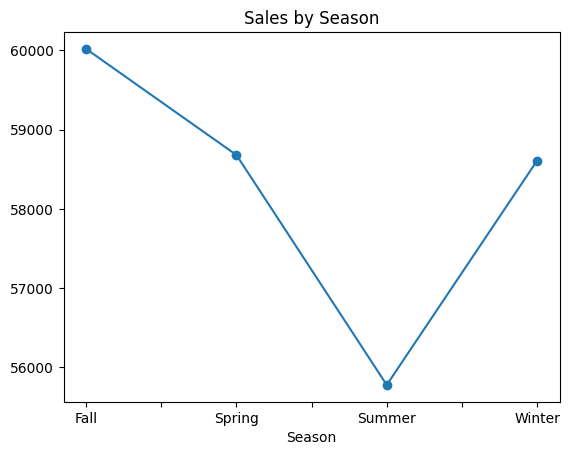

In [12]:
# Sales by Season
season_sales = df.groupby("Season")["Purchase Amount (USD)"].sum()
print("\nSales by Season:\n", season_sales)

season_sales.plot(kind='line', marker='o')
plt.title("Sales by Season")
plt.show()



Subscription Status:
 Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64


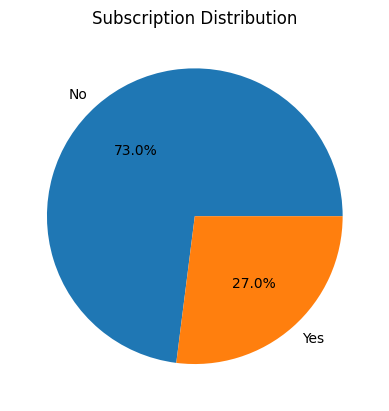

In [13]:
# Subscription Analysis
subscription_count = df["Subscription Status"].value_counts()
print("\nSubscription Status:\n", subscription_count)

subscription_count.plot(kind='pie', autopct='%1.1f%%')
plt.title("Subscription Distribution")
plt.ylabel("")
plt.show()

In [14]:
# Top 5 Customers
top_customers = df.groupby("Customer ID")["Purchase Amount (USD)"].sum().sort_values(ascending=False).head(5)
print("\nTop 5 Customers:\n", top_customers)


Top 5 Customers:
 Customer ID
1480    100
1457    100
1592    100
2072    100
1422    100
Name: Purchase Amount (USD), dtype: int64



Correlation Matrix:
                             Age  Previous Purchases  Purchase Amount (USD)
Age                    1.000000            0.040445              -0.010424
Previous Purchases     0.040445            1.000000               0.008063
Purchase Amount (USD) -0.010424            0.008063               1.000000


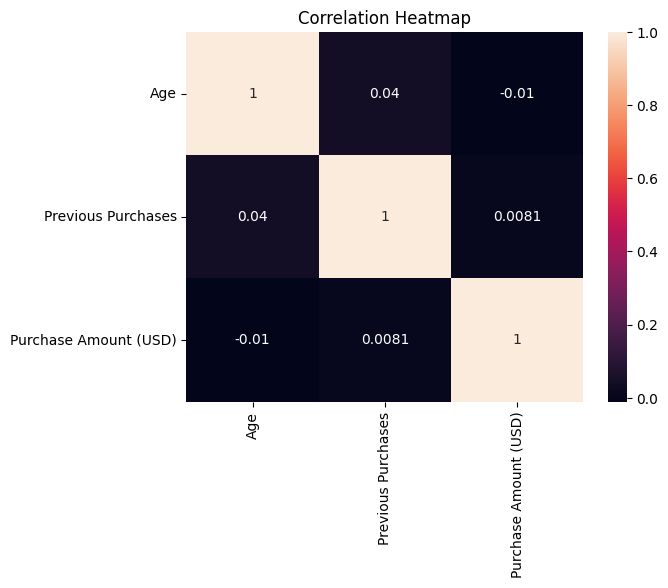

In [15]:
#Correlation Analysis
corr = df[["Age", "Previous Purchases", "Purchase Amount (USD)"]].corr()
print("\nCorrelation Matrix:\n", corr)

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()